#Semana 2 da capacitação
##Introdução a Ciência de Dados

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Lendo o dataset oferecido
vendas = pd.read_csv('../../data/vendas_brasil_1.csv', delimiter=",")


## Entregável 1: NumPy

In [3]:
#Criando os arrays, utilizando o dataframe do Pandas

preco_unit = vendas['preco_unitario'].to_numpy()
custo_unit = vendas['custo_unitario'].to_numpy()
quantidade = vendas['quantidade'].to_numpy()
descontoPorcentagem = vendas['desconto_pct'].to_numpy()
receita = vendas['receita_total'].to_numpy()
frete = vendas['frete'].to_numpy()


Cálculos utilizando esses arrays:

In [4]:
#Valor Bruto da Venda

valor_bruto = preco_unit*quantidade

print(valor_bruto)
print(f"A soma dos valores brutos de todas as vendas é {valor_bruto.sum()}")

[7393.9   937.4  1065.54 ...  386.05 1379.63 4229.64]
A soma dos valores brutos de todas as vendas é 71506224.03


In [5]:
#Valor do desconto
desconto = valor_bruto*descontoPorcentagem/100
print(desconto)
print(f"O valor total de descontos é {desconto.sum()}")

[384.4828    5.6244    7.45878 ...   0.      150.37967 422.964  ]
O valor total de descontos é 6784915.46658


In [6]:
#Custo total
custo_total = custo_unit*quantidade
print(custo_total)
print(f"O custo total de todas as vendas foi de {custo_total.sum()}")

[5617.5   675.75  859.6  ...  258.58 1170.61 3482.76]
O custo total de todas as vendas foi de 51855072.87


In [7]:
#Lucro Estimado
lucro = valor_bruto - desconto - custo_total
print(lucro)
print(f"O lucro de todas as vendas seria {lucro.sum()}")

[1391.9172   256.0256   198.48122 ...  127.47      58.64033  323.916  ]
O lucro de todas as vendas seria 12866235.69342


Máscaras Booleanas para verificar certas situações no dataset.

In [8]:
#Vendas com receita acima da média
media_receita = np.mean(receita)
receita_acima_media = receita > media_receita

receita[receita_acima_media]
print(f"Foram {receita[receita_acima_media].size} vendas com receita acima da média")

Foram 9236 vendas com receita acima da média


In [9]:
#Vendas com prezuizo
prezuizo = lucro < 0
lucro[prezuizo]
print(f"Foram {lucro[prezuizo].size} vendas que deram prejuizo")

Foram 2857 vendas que deram prejuizo


In [10]:
media_desconto = np.mean(desconto)
desconto_alto = desconto > media_desconto

desconto[desconto_alto]
print(f"Tiveram {desconto[desconto_alto].size} vendas comum desconto maior que a média.")

Tiveram 8321 vendas comum desconto maior que a média.


Algumas informações sobre a receita

In [11]:
print(f"Receita media: {np.mean(receita)}")
print(f"Maior receita: {np.max(receita)}")
print(f"Menor receita: {np.min(receita)}")

Receita media: 1891.6881729005502
Maior receita: 58430.28
Menor receita: 3.7


## Entregável 2: Pandas

Primeiramente, faremos a exploração inicial dos dados para descobrir quais são os dados oferecidos pelo dataset.

In [12]:
vendas.shape

(37617, 21)

A partir do shape, sabemos que o dataframe sendo trabalhado possui 37617 linhas e 21 colunas.

In [13]:
vendas.isna().sum()

data_venda               0
mes                      0
cidade                   0
canal_venda             50
categoria                0
produto                  0
vendedor                40
fidelidade_cliente       0
preco_unitario           0
custo_unitario           0
margem_pct              82
quantidade               0
desconto_pct             0
receita_total            0
frete                 1879
avaliacao_cliente     2955
prazo_entrega_dias    1504
devolucao                0
entrega_no_prazo         0
alta_temporada           0
flag_outlier_preco       0
dtype: int64

Mas, a partir desses metodos, sabemos que há dados faltando/sendo marcados como NA/None no dataframe sendo trabalhado.

In [14]:
vendas.info()

<class 'pandas.DataFrame'>
RangeIndex: 37617 entries, 0 to 37616
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   data_venda          37617 non-null  str    
 1   mes                 37617 non-null  int64  
 2   cidade              37617 non-null  str    
 3   canal_venda         37567 non-null  str    
 4   categoria           37617 non-null  str    
 5   produto             37617 non-null  str    
 6   vendedor            37577 non-null  str    
 7   fidelidade_cliente  37617 non-null  str    
 8   preco_unitario      37617 non-null  float64
 9   custo_unitario      37617 non-null  float64
 10  margem_pct          37535 non-null  float64
 11  quantidade          37617 non-null  int64  
 12  desconto_pct        37617 non-null  float64
 13  receita_total       37617 non-null  float64
 14  frete               35738 non-null  float64
 15  avaliacao_cliente   34662 non-null  float64
 16  prazo_entrega_d

A partir do metodo info, sabemos que temos acesso a 21 colunas. Além disso, aprendemos que cada coluna possui um tipo de dado diferente entre: bool (True ou False), int (numeros inteiros), float (numeros não necessariamente inteiros) e str ("texto").

Assim, sabemos que as colunas preco_unitario, custo_unitario, margem_pct, desconto_pct, receita_total, frete, avaliacao_cliente, prazo_entrega_dias são floats, enquanto mes e quantidade são int contabilizando 10 colunas númericas.

Já as colunas data_venda (str, porém representa uma data), cidade, canal_venda, categoria, produto, vendedor, fidelidade_cliente são strings, enquanto devolucao, entrega_no_prazo, alta_temporada, flag_outlier_preco são booleanos contabilizando 11 colunas categóricas.

In [15]:
vendas.describe()

,mes,preco_unitario,custo_unitario,margem_pct,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias
count,37617.000000,37617.000000,37617.000000,37535.000000,37617.000000,37617.000000,37617.000000,35738.000000,34662.000000,36113.000000
mean,6.517691,253.214933,183.620999,22.714776,7.481750,9.494048,1891.688173,29.885737,3.912094,10.017113
std,3.439296,316.742367,231.376757,8.670213,4.322273,9.097484,2972.445759,24.765161,0.932256,5.477487
min,1.000000,4.940000,3.010000,-0.570000,1.000000,0.000000,3.700000,3.750000,1.000000,1.000000
25%,4.000000,68.960000,49.550000,16.380000,4.000000,0.300000,364.280000,12.190000,3.490000,5.000000
50%,7.000000,111.300000,80.990000,22.700000,7.000000,9.000000,789.570000,22.250000,4.010000,10.000000
75%,9.000000,257.680000,186.570000,29.250000,11.000000,19.000000,1853.210000,39.480000,4.520000,15.000000
max,12.000000,9008.600000,6578.260000,44.270000,161.000000,26.000000,58430.280000,243.820000,5.000000,19.000000


A partir do metodo describe, temos mais informações sobre as colunas númericas, tais como a média dos valores (mean), o intervalo  dos valores (min o e o max), o desvio padrão desses dados (std), além da quantidade de valores considerados (count), pois o Pandas  não  utiliza dados nulos/vazios nessa consideração e, como no dataset, há dados faltando, então o count não é igual ao número de linhas.

In [16]:
#Tratamento da coluna de datas para datetime
vendas['data_venda'] = pd.to_datetime(vendas['data_venda'], format="mixed")
print(vendas['data_venda'].dtype) #checando se a conversão deu certo

datetime64[us]


In [17]:
vendas['cidade'].unique()

<ArrowStringArray>
[ 'Rio de Janeiro',          'Manaus',         'Goiânia',       'Fortaleza',
  'Belo Horizonte',          'Recife',       'São Paulo',    'Porto Alegre',
        'Salvador',        'Curitiba',        'salvador', 'Belo Horizonte ',
  'Rio de janeiro',         'Curtiba',       'Curitiba ',              'SP',
      ' Fortaleza',        'curitiba',              'RJ',        'S. Paulo',
       ' Salvador',         'Manaus ',       'São paulo',      'Fortaleza ',
       'Sao Paulo',              'BH', 'Rio de Janeiro ', ' Belo Horizonte',
         ' Recife',        'Slavador',  'Belo horizonte',             'Rio',
       ' Curitiba',         ' Manaus',        ' Goiânia',         'Recife ',
    'B. Horizonte',   'Porto Alegre ',  'Rio De Janeiro',      'São Paulo ',
        'Goiânia ',   ' Porto Alegre',       'Salvador ', ' Rio de Janeiro',
      ' São Paulo']
Length: 45, dtype: str

Utilizando o método unique, vemos que a coluna 'cidade' possui diversas representações para a mesma informação (Rio de Janeiro, Rio de janeiro, RJ são todos indicativos da mesma cidade, mas com grafias diferentes). Por isso, a fim de reduzir essa discrância essa categoria cidade será tratada de forma que todos os dados estejam escritos da seguinte forma: capitalização das primeiras letras de cada palavra do Estado (com exceção das preposições que ficaram em maiusculo) e sem espaços antes ou depois.

In [18]:
#Primeiro, tiraremos os espaços antes e depois dos nomes da cidade
vendas["cidade"] = vendas["cidade"].str.strip()

vendas['cidade'].unique()

<ArrowStringArray>
['Rio de Janeiro',         'Manaus',        'Goiânia',      'Fortaleza',
 'Belo Horizonte',         'Recife',      'São Paulo',   'Porto Alegre',
       'Salvador',       'Curitiba',       'salvador', 'Rio de janeiro',
        'Curtiba',             'SP',       'curitiba',             'RJ',
       'S. Paulo',      'São paulo',      'Sao Paulo',             'BH',
       'Slavador', 'Belo horizonte',            'Rio',   'B. Horizonte',
 'Rio De Janeiro']
Length: 25, dtype: str

Agora com essa redução, vamos criar um dicionário que corrija os outros erros como o de capitalização, de abreviação ou de digitação.

In [19]:
correcao = {
    'Curtiba' : 'Curitiba',
    'S. Paulo': 'São Paulo',
    'Slavador' : 'Salvador',
    'Rio De Janeiro' : 'Rio de Janeiro',
    'SP' : 'São Paulo',
    'São paulo' : 'São Paulo',
    'Belo horizonte' : 'Belo Horizonte',
    'salvador' : 'Salvador',
    'curitiba' : 'Curitiba',
    'Sao Paulo' : 'São  Paulo',
    'Rio' : 'Rio de Janeiro',
    'Rio de janeiro' : 'Rio de Janeiro',
    'RJ' : 'Rio de Janeiro',
    'BH' : 'Belo Horizonte',
    'B. Horizonte' : 'Belo Horizonte',
    'São  Paulo' : 'São Paulo'
}

vendas["cidade"] = vendas["cidade"].replace(correcao)
vendas['cidade'].unique()

<ArrowStringArray>
['Rio de Janeiro',         'Manaus',        'Goiânia',      'Fortaleza',
 'Belo Horizonte',         'Recife',      'São Paulo',   'Porto Alegre',
       'Salvador',       'Curitiba',     'São  Paulo']
Length: 11, dtype: str

A mesma coisa pode ser feita para a coluna 'canal_venda'.

In [20]:
vendas['canal_venda'].unique()

<ArrowStringArray>
[ 'App Mobile',    'Site Web', 'Loja Física', 'Marketplace',  'Televendas',
  'APP Mobile',    'site web',    'Site web',  'app mobile',     'SiteWeb',
           nan, 'Loja Fisica',  'App mobile', 'loja física', 'Loja fisica']
Length: 15, dtype: str

Neste caso, manteremos uma lógica parecida com os cidades para renomear com capitalização em cada palavra e utilizando acentos.

In [21]:
canais ={
    'APP Mobile' : 'App Mobile',
    'site web' : 'Site Web',
    'Site web' : 'Site Web',
    'app mobile' : 'App Mobile',
    'App mobile' : 'App Mobile',
    'SiteWeb' : 'Site Web',
    'loja física' : 'Loja Física',
    'Loja fisica' : 'Loja Física'
}
vendas['canal_venda'] = vendas['canal_venda'].replace(canais)
vendas['canal_venda'].unique()

<ArrowStringArray>
[ 'App Mobile',    'Site Web', 'Loja Física', 'Marketplace',  'Televendas',
           nan, 'Loja Fisica']
Length: 7, dtype: str

Usando filtros para analisar os dados:

In [22]:
vendasMaioresQue10000 = vendas[vendas['receita_total'] > 10000]


vendasMaioresQue10000[['data_venda', 'canal_venda', 'receita_total']]

,data_venda,canal_venda,receita_total
20,2022-12-10,Site Web,11246.38
45,2023-04-30,Site Web,13464.96
50,2023-01-23,Site Web,11934.03
85,2023-12-03,App Mobile,10020.05
88,2023-12-21,Site Web,12543.13
...,...,...,...
37476,2023-08-30,Site Web,13590.04
37524,2023-12-31,Televendas,16872.25
37530,2023-12-31,App Mobile,10942.58
37566,2023-12-31,Loja Física,10598.02


São 1258 vendas com receitas acima de 10000.

In [23]:
vendasDevolvidas = vendas[vendas['devolucao']]

vendasDevolvidas[['data_venda', 'canal_venda', 'devolucao']]

,data_venda,canal_venda,devolucao
1,2023-03-12,Site Web,True
2,2022-09-28,App Mobile,True
7,2023-09-07,App Mobile,True
18,2023-10-24,Site Web,True
21,2023-05-07,Loja Física,True
...,...,...,...
37522,2023-12-31,Marketplace,True
37525,2023-12-31,Loja Física,True
37533,2023-12-31,App Mobile,True
37583,2023-12-31,Loja Física,True


Ao total, 3532 vendas foram devolvidas.

Usando agrupamento para entender dados.

In [24]:
vendas.groupby(['categoria'])[['receita_total']].sum()


,receita_total
categoria,
Alimentação,3331601.51
Eletrônicos,45017479.88
Esportes,11567480.75
Livros,4462597.93
Vestuário,6780473.93


A maior receita é da categoria de eletrônicos.

In [25]:
vendas.groupby(['canal_venda']).count()

,data_venda,mes,cidade,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,margem_pct,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco
canal_venda,,,,,,,,,,,,,,,,,,,,
App Mobile,11258,11258,11258,11258,11258,11241,11258,11258,11258,11233,11258,11258,11258,10722,10405,10800,11258,11258,11258,11258
Loja Fisica,18,18,18,18,18,18,18,18,18,18,18,18,18,16,17,17,18,18,18,18
Loja Física,7480,7480,7480,7480,7480,7470,7480,7480,7480,7463,7480,7480,7480,7092,6865,7159,7480,7480,7480,7480
Marketplace,5604,5604,5604,5604,5604,5601,5604,5604,5604,5594,5604,5604,5604,5314,5155,5398,5604,5604,5604,5604
Site Web,11346,11346,11346,11346,11346,11337,11346,11346,11346,11319,11346,11346,11346,10784,10476,10910,11346,11346,11346,11346
Televendas,1861,1861,1861,1861,1861,1860,1861,1861,1861,1858,1861,1861,1861,1762,1698,1781,1861,1861,1861,1861


Site Web foi o canal de vendas que realizou mais vendas.

In [26]:
vendas.groupby(['cidade'])[['receita_total']].sum()

,receita_total
cidade,
Belo Horizonte,6914747.61
Curitiba,6993175.07
Fortaleza,7242081.82
Goiânia,7178113.69
Manaus,7459161.23
Porto Alegre,7048428.17
Recife,7662241.79
Rio de Janeiro,6880176.34
Salvador,6918656.01


Recife foi a cidade com a maior receita total.

Criação de novas colunas:

In [27]:
vendas['valor_bruto'] = vendas['quantidade']*vendas['preco_unitario']
vendas['desconto'] = vendas['valor_bruto']*vendas['desconto_pct']/100
vendas['lucro'] = vendas['valor_bruto'] - vendas['desconto'] - vendas['custo_unitario']
vendas['ano'] = vendas['data_venda'].dt.year

vendas.head()

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco,valor_bruto,desconto,lucro,ano
0,2022-04-13,4,Rio de Janeiro,App Mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,...,4.92,5.0,False,True,False,False,7393.90,384.48280,6447.66720,2022
1,2023-03-12,3,Manaus,Site Web,Vestuário,Camiseta,Elisa Costa,Bronze,187.48,135.15,...,4.98,19.0,True,False,False,False,937.40,5.62440,796.62560,2023
2,2022-09-28,9,Goiânia,App Mobile,Vestuário,Tênis,João Vieira,Bronze,76.11,61.40,...,3.47,NaN,True,True,False,False,1065.54,7.45878,996.68122,2022
3,2022-04-17,4,Fortaleza,Site Web,Vestuário,Calça Jeans,Carla Mendes,Bronze,145.86,88.53,...,4.50,16.0,False,True,False,False,1604.46,9.62676,1506.30324,2022
4,2022-03-13,3,Belo Horizonte,App Mobile,Esportes,Bicicleta,João Vieira,Bronze,133.92,107.25,...,3.49,13.0,False,True,False,False,133.92,26.11440,0.55560,2022


## Entregável 3: Seaborn

Criando gráficos sobre esse dataframe

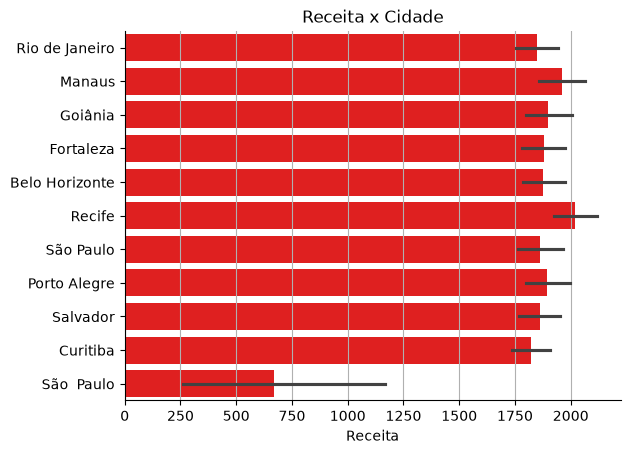

In [28]:
sns.barplot(data=vendas, x = vendas['receita_total'], y = 'cidade', color='red')
plt.title("Receita x Cidade")
plt.xlabel("Receita")
plt.ylabel("")
plt.grid(axis="x")
sns.despine()


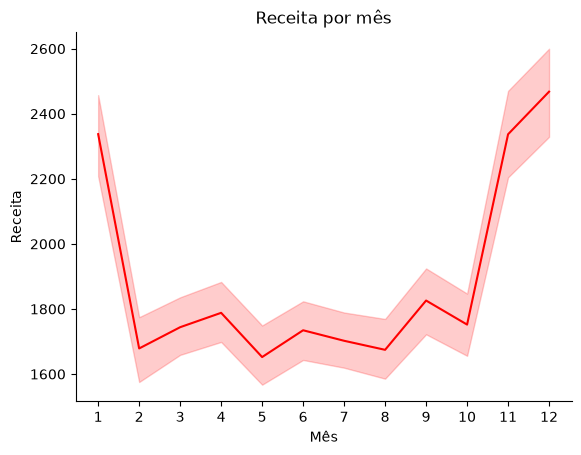

In [29]:

sns.lineplot(data=vendas, x=vendas['mes'], y=vendas['receita_total'], color='red')
plt.title("Receita por mês")
plt.xlabel("Mês")
plt.ylabel("Receita")
plt.xticks(vendas['mes'].unique())
sns.despine()
plt.show()


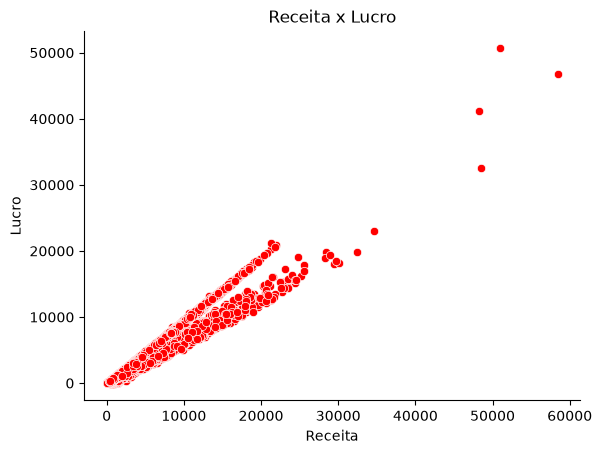

In [30]:
sns.scatterplot(data=vendas, x=vendas['receita_total'], y=vendas['lucro'], color='red')

plt.title("Receita x Lucro")
plt.xlabel("Receita")
plt.ylabel("Lucro")
sns.despine()
plt.show()

<Axes: >

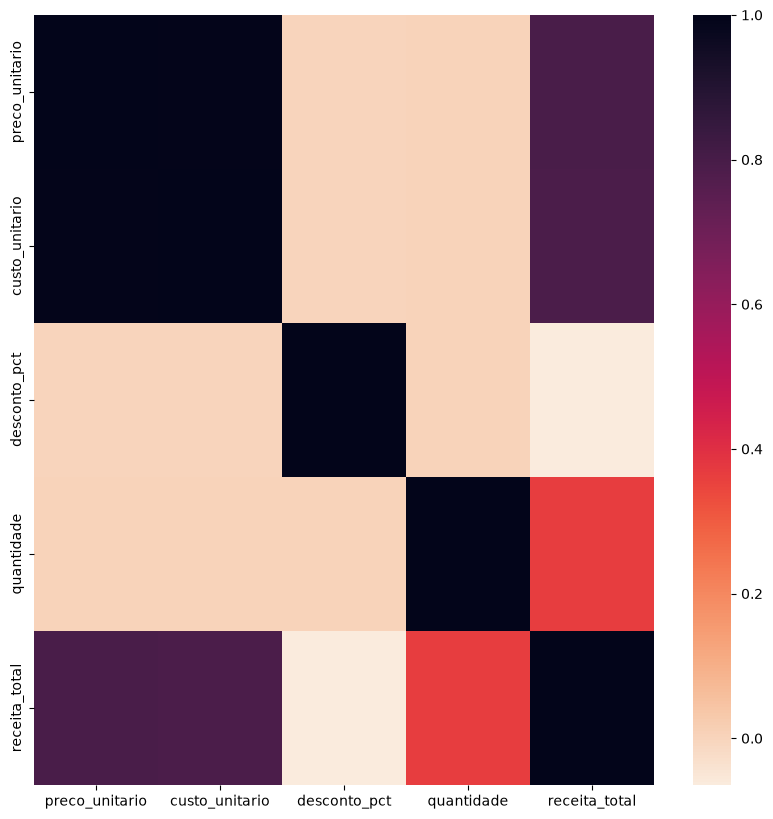

In [45]:
dados_numericos = vendas[['preco_unitario', 'custo_unitario', 'desconto_pct', 'quantidade', 'receita_total']]
corr = dados_numericos.corr()
plt.figure(figsize=(10,10))
sns.despine()
sns.heatmap(corr, cmap="rocket_r")

 